In [ ]:
import pandas as pd

df = pd.read_csv("Tar_null.csv",encoding='cp949')

In [ ]:
df['Target'] =df['업체분류'].map({"정상":0,"부실":1})

In [ ]:
df['Target'].value_counts()

Target
0    20279
1     1086
Name: count, dtype: int64

In [ ]:
target_cols = ['결산년도',
    'F06','F07','F10','F11','F13','F17','F19','F21','F23',
    'F36','F38','F40','F44','F45','F47','Target'
]

selected_idx = [df.columns.get_loc(col) for col in target_cols if col in df.columns]

data = df.iloc[:, selected_idx]

In [ ]:
data['Target'].value_counts()

Target
0    20279
1     1086
Name: count, dtype: int64

In [ ]:
train = data[data['결산년도']<=2023].drop(columns=['결산년도'])
test = data[data['결산년도']==2024].drop(columns=['결산년도'])

In [ ]:
print(train['Target'].value_counts())
print(test['Target'].value_counts())

Target
0    17974
1     1054
Name: count, dtype: int64
Target
0    2305
1      32
Name: count, dtype: int64


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19028 entries, 0 to 21362
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F06     19028 non-null  float64
 1   F07     19028 non-null  float64
 2   F10     19028 non-null  float64
 3   F11     19028 non-null  float64
 4   F13     19028 non-null  float64
 5   F17     19028 non-null  float64
 6   F19     19028 non-null  float64
 7   F21     19028 non-null  float64
 8   F23     19028 non-null  float64
 9   F36     19028 non-null  float64
 10  F38     19028 non-null  float64
 11  F40     19028 non-null  float64
 12  F44     19028 non-null  float64
 13  F45     19028 non-null  float64
 14  F47     19028 non-null  float64
 15  Target  19028 non-null  int64  
dtypes: float64(15), int64(1)
memory usage: 2.5 MB


X_train shape: (12177, 15)
X_valid shape: (3045, 15)
X_test shape : (3806, 15)
Train positive ratio: 0.05535025047220169

RandomForest | RandomizedSearchCV
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Params:
{'smote_tomek__sampling_strategy': 0.15, 'model__n_estimators': 700, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__criterion': 'entropy'}
Best CV avg_precision: 0.5539054442440793

----------------------------------------------------------------------------------------------------
[RandomForest] FINAL
----------------------------------------------------------------------------------------------------
Best Params:
{'smote_tomek__sampling_strategy': 0.15, 'model__n_estimators': 700, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__criterion': 'entropy'}

Best CV avg_precision: 0.553905
Validation Best Thre

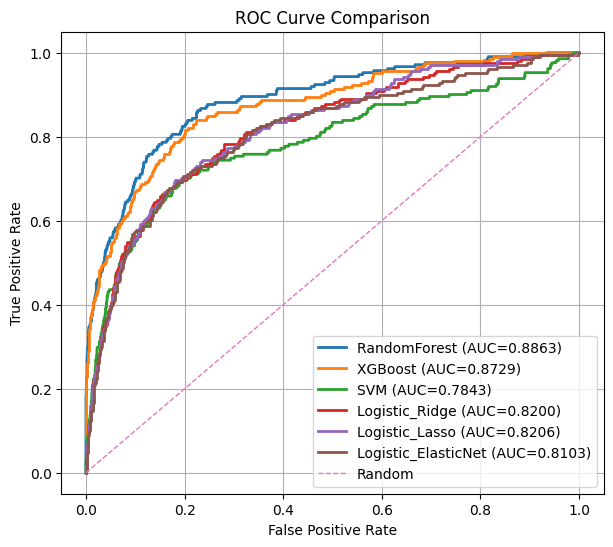

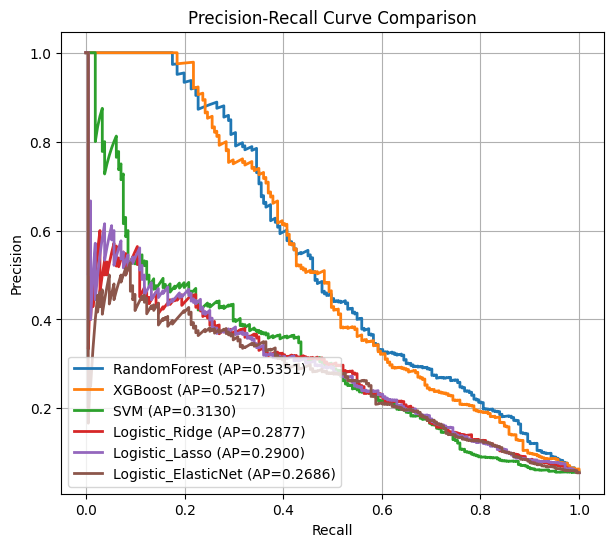

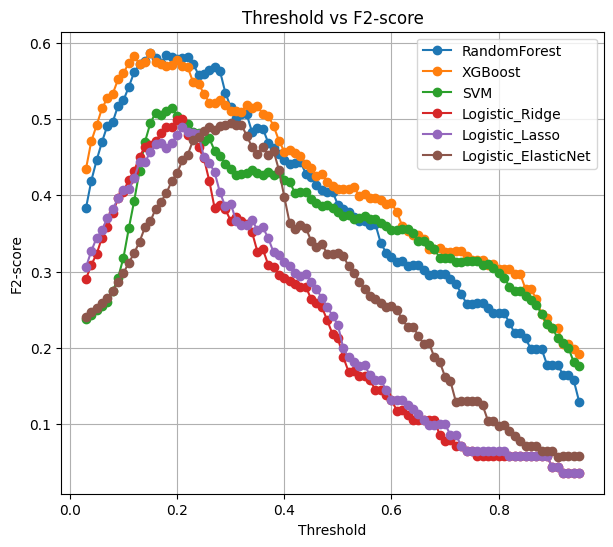

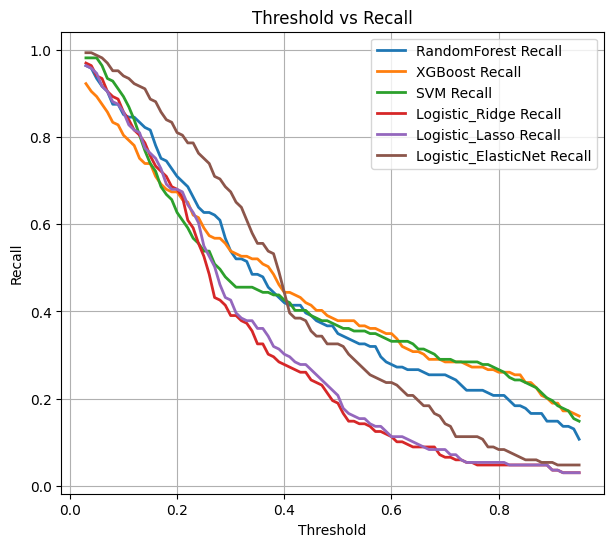

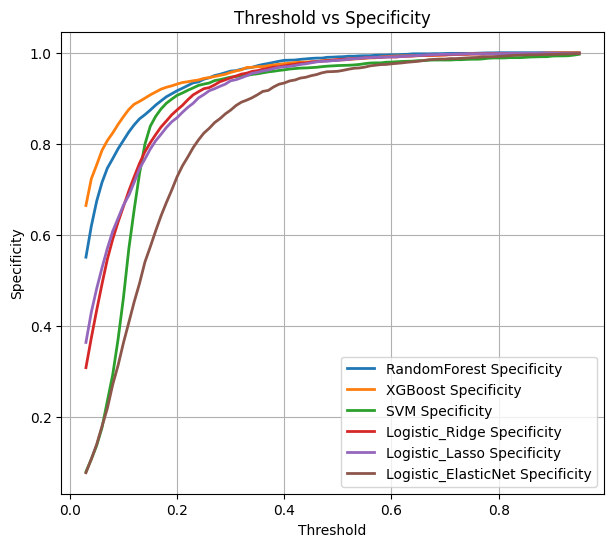


RandomForest TOP VARIABLE IMPORTANCE
   feature  importance
0      F36    0.128040
1      F45    0.100840
2      F47    0.098766
3      F13    0.079022
4      F21    0.068479
5      F11    0.067155
6      F40    0.066184
7      F07    0.056244
8      F17    0.052483
9      F10    0.052190
10     F38    0.050574
11     F44    0.048668
12     F06    0.048148
13     F19    0.042535
14     F23    0.040671

XGBoost TOP VARIABLE IMPORTANCE
   feature  importance
0      F45    0.195389
1      F36    0.129603
2      F47    0.113558
3      F21    0.066638
4      F40    0.061634
5      F13    0.055396
6      F11    0.054016
7      F17    0.049938
8      F07    0.048254
9      F06    0.043572
10     F38    0.038430
11     F23    0.037700
12     F44    0.036458
13     F10    0.036406
14     F19    0.033007

SVM TOP VARIABLE IMPORTANCE
   feature  importance
0      F11    0.165981
1      F13    0.104701
2      F17    0.071850
3      F10    0.065815
4      F47    0.049113
5      F21    0.045303
6  

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

warnings.filterwarnings("ignore")


# =========================================================
# 1. Threshold 선택 함수
# =========================================================
def find_best_threshold(y_true, y_proba, min_precision=0.30):
    thresholds = np.arange(0.03, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if (4 * prec + rec) == 0:
            f2 = 0
        else:
            f2 = (5 * prec * rec) / (4 * prec + rec)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": f2 + 0.03 * rec
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


# =========================================================
# 2. 평가 함수
# =========================================================
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if (4 * prec + rec) == 0:
        f2 = 0
    else:
        f2 = (5 * prec * rec) / (4 * prec + rec)

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_test, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


# =========================================================
# 3. 변수 중요도 함수
# =========================================================
def get_feature_importance(model, model_name, X_valid, y_valid, feature_names, top_n=20):
    if model_name in ["RandomForest", "XGBoost"]:
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.named_steps["model"].feature_importances_
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    elif model_name == "SVM":
        perm = permutation_importance(
            model,
            X_valid,
            y_valid,
            n_repeats=10,
            random_state=42,
            scoring="f1",
            n_jobs=-1
        )
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": perm.importances_mean
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    elif model_name in ["Logistic_Ridge", "Logistic_Lasso", "Logistic_ElasticNet"]:
        coef = model.named_steps["model"].coef_[0]
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef),
            "direction": np.where(coef >= 0, "positive(+)", "negative(-)")
        }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    return None


# =========================================================
# 4. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape :", X_test.shape)
print("Train positive ratio:", y_train.mean())


# =========================================================
# 5. CV, Scoring
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


# =========================================================
# 6. 모델 정의
# =========================================================
smote_ratio_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]

model_configs = {
    "RandomForest": {
        "pipeline": ImbPipeline([
            ("smote_tomek", SMOTETomek(random_state=42)),
            ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_dist": {
            "smote_tomek__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [300, 500, 700, 1000],
            "model__max_depth": [None, 4, 6, 8, 10, 15],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", None],
            "model__criterion": ["gini", "entropy"]
        },
        "n_iter": 30
    },

    "XGBoost": {
        "pipeline": ImbPipeline([
            ("smote_tomek", SMOTETomek(random_state=42)),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_dist": {
            "smote_tomek__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 300, 500, 700],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [3, 4, 5, 6],
            "model__min_child_weight": [3, 5, 7, 10],
            "model__subsample": [0.7, 0.8, 0.9],
            "model__colsample_bytree": [0.6, 0.7, 0.8],
            "model__gamma": [0, 0.1, 0.3, 0.5],
            "model__reg_alpha": [0, 0.1, 1, 5],
            "model__reg_lambda": [1, 5, 10, 20]
        },
        "n_iter": 30
    },

    "SVM": {
        "pipeline": ImbPipeline([
            ("smote_tomek", SMOTETomek(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42))
        ]),
        "param_dist": {
            "smote_tomek__sampling_strategy": smote_ratio_grid,
            "model__C": [0.1, 1, 3, 5, 10, 30],
            "model__gamma": ["scale", 0.001, 0.01, 0.05, 0.1],
            "model__kernel": ["rbf"]
        },
        "n_iter": 25
    },

    "Logistic_Ridge": {
        "pipeline": ImbPipeline([
            ("smote_tomek", SMOTETomek(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                random_state=42,
                penalty="l2"
            ))
        ]),
        "param_dist": {
            "smote_tomek__sampling_strategy": smote_ratio_grid,
            "model__C": [0.01, 0.05, 0.1, 0.5, 1, 3, 5, 10, 30]
        },
        "n_iter": 20
    },

    "Logistic_Lasso": {
        "pipeline": ImbPipeline([
            ("smote_tomek", SMOTETomek(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                random_state=42,
                penalty="l1"
            ))
        ]),
        "param_dist": {
            "smote_tomek__sampling_strategy": smote_ratio_grid,
            "model__C": [0.01, 0.05, 0.1, 0.5, 1, 3, 5, 10, 30]
        },
        "n_iter": 20
    },

    "Logistic_ElasticNet": {
        "pipeline": ImbPipeline([
            ("smote_tomek", SMOTETomek(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                solver="saga",
                random_state=42,
                penalty="elasticnet"
            ))
        ]),
        "param_dist": {
            "smote_tomek__sampling_strategy": smote_ratio_grid,
            "model__C": [0.01, 0.05, 0.1, 0.5, 1, 3, 5, 10, 30],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        },
        "n_iter": 20
    }
}


# =========================================================
# 7. 모델 학습 + threshold tuning + test 평가
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}
importance_tables = {}

for model_name, cfg in model_configs.items():
    print("\n" + "=" * 100)
    print(f"{model_name} | RandomizedSearchCV")
    print("=" * 100)

    X_train_use = X_train.copy()
    X_valid_use = X_valid.copy()
    X_test_use = X_test.copy()

    search = RandomizedSearchCV(
        estimator=cfg["pipeline"],
        param_distributions=cfg["param_dist"],
        n_iter=cfg["n_iter"],
        scoring=scoring,
        refit="avg_precision",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    search.fit(X_train_use, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    print("\nBest Params:")
    print(search.best_params_)
    print("Best CV avg_precision:", search.best_score_)

    valid_proba = best_model.predict_proba(X_valid_use)[:, 1]
    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        min_precision=0.30
    )

    threshold_tables[model_name] = threshold_df
    best_threshold = float(best_threshold_row["threshold"])

    eval_result = evaluate_model(
        model=best_model,
        X_test=X_test_use,
        y_test=y_test,
        threshold=best_threshold
    )

    fpr, tpr, _ = roc_curve(y_test, eval_result["y_proba"])
    roc_data[model_name] = (fpr, tpr, eval_result["ROC_AUC"])

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, eval_result["y_proba"])
    pr_data[model_name] = (pr_recall, pr_precision, eval_result["Avg_Precision"])

    importance_df = get_feature_importance(
        model=best_model,
        model_name=model_name,
        X_valid=X_valid_use,
        y_valid=y_valid,
        feature_names=X_train_use.columns.tolist(),
        top_n=20
    )

    importance_tables[model_name] = importance_df

    print("\n" + "-" * 100)
    print(f"[{model_name}] FINAL")
    print("-" * 100)
    print("Best Params:")
    print(search.best_params_)
    print(f"\nBest CV avg_precision: {search.best_score_:.6f}")
    print(f"Validation Best Threshold (F2+Recall, precision>=0.30): {best_threshold:.2f}")

    print("\n[Test Set Performance]")
    print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
    print(f"Recall            : {eval_result['Recall']:.6f}")
    print(f"Specificity       : {eval_result['Specificity']:.6f}")
    print(f"Precision         : {eval_result['Precision']:.6f}")
    print(f"F1-score          : {eval_result['F1_score']:.6f}")
    print(f"F2-score          : {eval_result['F2_score']:.6f}")
    print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
    print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        eval_result["Confusion_Matrix"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(eval_result["Classification_Report"])

    print("\nTop Variable Importance:")
    print(importance_df)

    results.append({
        "Model": model_name,
        "Num_Features": X_train_use.shape[1],
        "Best_CV_avg_precision": search.best_score_,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": eval_result["Accuracy"],
        "Recall": eval_result["Recall"],
        "Specificity": eval_result["Specificity"],
        "Precision": eval_result["Precision"],
        "F1_score": eval_result["F1_score"],
        "F2_score": eval_result["F2_score"],
        "ROC_AUC": eval_result["ROC_AUC"],
        "Avg_Precision": eval_result["Avg_Precision"],
        "Best_Params": search.best_params_
    })


# =========================================================
# 8. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F2_score", "Recall", "F1_score", "Avg_Precision", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(results_df[[
    "Model",
    "Num_Features",
    "Best_CV_avg_precision",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Specificity",
    "Precision",
    "F1_score",
    "F2_score",
    "ROC_AUC",
    "Avg_Precision"
]])


# =========================================================
# 9. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 10. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_score:.4f})"
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 11. Threshold vs F2
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f2"], marker="o", label=name)
plt.xlabel("Threshold")
plt.ylabel("F2-score")
plt.title("Threshold vs F2-score")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 12. Threshold vs Recall / Specificity
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["recall"], linewidth=2, label=f"{name} Recall")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["specificity"], linewidth=2, label=f"{name} Specificity")
plt.xlabel("Threshold")
plt.ylabel("Specificity")
plt.title("Threshold vs Specificity")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 13. 변수 중요도 재출력
# =========================================================
for name, imp_df in importance_tables.items():
    print("\n" + "=" * 100)
    print(f"{name} TOP VARIABLE IMPORTANCE")
    print("=" * 100)
    print(imp_df)


# =========================================================
# 14. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print(f"최종 추천 모델: {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")


# =========================================================
# 1. Threshold 선택 함수
# =========================================================
def find_best_threshold(y_true, y_proba, min_precision=0.30):
    thresholds = np.arange(0.03, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": f2 + 0.03 * rec
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


# =========================================================
# 2. 평가 함수
# =========================================================
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_test, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


# =========================================================
# 3. 변수 중요도 함수
# =========================================================
def get_feature_importance(model, model_name, feature_names, top_n=20):
    if model_name in ["RandomForest", "XGBoost"]:
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.named_steps["model"].feature_importances_
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    elif model_name == "Logistic":
        coef = model.named_steps["model"].coef_[0]
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef),
            "direction": np.where(coef >= 0, "positive(+)", "negative(-)")
        }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    return None


# =========================================================
# 4. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape :", X_test.shape)
print("Train positive ratio:", y_train.mean())


# =========================================================
# 5. CV, Scoring
# =========================================================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


# =========================================================
# 6. 모델 정의
# =========================================================
smote_ratio_grid = [0.10, 0.15, 0.20, 0.25]

model_configs = {
    "Logistic": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                penalty="l2",
                random_state=42
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__C": [0.1, 0.5, 1, 3, 5]
        },
        "n_iter": 8
    },

    "RandomForest": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=None
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 6, 10, 15],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        },
        "n_iter": 15
    },

    "XGBoost": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 300, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__min_child_weight": [3, 5, 7],
            "model__subsample": [0.8, 0.9],
            "model__colsample_bytree": [0.7, 0.8],
            "model__reg_lambda": [1, 5, 10],
            "model__reg_alpha": [0, 0.1, 1]
        },
        "n_iter": 15
    }
}


# =========================================================
# 7. 모델 학습 + Threshold Tuning + Test 평가
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}
importance_tables = {}

for model_name, cfg in model_configs.items():
    print("\n" + "=" * 100)
    print(f"{model_name} | RandomizedSearchCV")
    print("=" * 100)

    search = RandomizedSearchCV(
        estimator=cfg["pipeline"],
        param_distributions=cfg["param_dist"],
        n_iter=cfg["n_iter"],
        scoring=scoring,
        refit="avg_precision",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    print("\nBest Params:")
    print(search.best_params_)
    print("Best CV avg_precision:", search.best_score_)

    # Validation set에서 threshold 선택
    valid_proba = best_model.predict_proba(X_valid)[:, 1]
    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        min_precision=0.30
    )

    threshold_tables[model_name] = threshold_df
    best_threshold = float(best_threshold_row["threshold"])

    # Test set 평가
    eval_result = evaluate_model(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        threshold=best_threshold
    )

    # ROC / PR Curve 저장
    fpr, tpr, _ = roc_curve(y_test, eval_result["y_proba"])
    roc_data[model_name] = (fpr, tpr, eval_result["ROC_AUC"])

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, eval_result["y_proba"])
    pr_data[model_name] = (pr_recall, pr_precision, eval_result["Avg_Precision"])

    # 변수 중요도
    importance_df = get_feature_importance(
        model=best_model,
        model_name=model_name,
        feature_names=X_train.columns.tolist(),
        top_n=20
    )
    importance_tables[model_name] = importance_df

    print("\n" + "-" * 100)
    print(f"[{model_name}] FINAL")
    print("-" * 100)
    print("Best Params:")
    print(search.best_params_)
    print(f"\nBest CV avg_precision: {search.best_score_:.6f}")
    print(f"Validation Best Threshold: {best_threshold:.2f}")

    print("\n[Test Set Performance]")
    print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
    print(f"Recall            : {eval_result['Recall']:.6f}")
    print(f"Specificity       : {eval_result['Specificity']:.6f}")
    print(f"Precision         : {eval_result['Precision']:.6f}")
    print(f"F1-score          : {eval_result['F1_score']:.6f}")
    print(f"F2-score          : {eval_result['F2_score']:.6f}")
    print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
    print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        eval_result["Confusion_Matrix"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(eval_result["Classification_Report"])

    print("\nTop Variable Importance:")
    print(importance_df)

    results.append({
        "Model": model_name,
        "Num_Features": X_train.shape[1],
        "Best_CV_avg_precision": search.best_score_,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": eval_result["Accuracy"],
        "Recall": eval_result["Recall"],
        "Specificity": eval_result["Specificity"],
        "Precision": eval_result["Precision"],
        "F1_score": eval_result["F1_score"],
        "F2_score": eval_result["F2_score"],
        "ROC_AUC": eval_result["ROC_AUC"],
        "Avg_Precision": eval_result["Avg_Precision"],
        "Best_Params": search.best_params_
    })


# =========================================================
# 8. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F1_score", "Recall", "Avg_Precision", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(results_df[[
    "Model",
    "Num_Features",
    "Best_CV_avg_precision",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Specificity",
    "Precision",
    "F1_score",
    "F2_score",
    "ROC_AUC",
    "Avg_Precision"
]])


# =========================================================
# 9. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 10. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_score:.4f})"
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 11. Threshold vs F1 / Recall
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f1"], marker="o", label=name)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["recall"], linewidth=2, label=f"{name} Recall")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 12. 변수 중요도 재출력
# =========================================================
for name, imp_df in importance_tables.items():
    print("\n" + "=" * 100)
    print(f"{name} TOP VARIABLE IMPORTANCE")
    print("=" * 100)
    print(imp_df)


# =========================================================
# 13. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print(f"최종 추천 모델: {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])


# =========================================================
# 14. SHAP 분석
# =========================================================
# SHAP은 최종 추천 모델이 XGBoost 또는 RandomForest일 때만 권장
# Logistic이 최종 추천 모델이면 계수 해석을 사용하면 됨.

try:
    import shap

    shap_model_name = best_model_name

    if shap_model_name in ["XGBoost", "RandomForest"]:
        print("\n" + "=" * 100)
        print(f"SHAP Analysis for {shap_model_name}")
        print("=" * 100)

        final_model = best_models[shap_model_name]
        tree_model = final_model.named_steps["model"]

        # SHAP 속도 조절용 샘플링
        sample_size = min(500, len(X_valid))
        X_shap = X_valid.sample(sample_size, random_state=42)

        explainer = shap.TreeExplainer(tree_model)
        shap_values = explainer.shap_values(X_shap)

        # XGBoost는 보통 shap_values가 array
        # RandomForest는 경우에 따라 list로 나올 수 있음
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar")
        shap.summary_plot(shap_values_to_plot, X_shap)

    else:
        print("\n최종 추천 모델이 Logistic이므로 SHAP 대신 회귀계수 기반 해석을 권장합니다.")
        print(importance_tables["Logistic"])

except ImportError:
    print("\nshap 패키지가 설치되어 있지 않습니다.")
    print("설치 후 다시 실행하세요: pip install shap")